# Logistic Regression — Bank Marketing Case Study
## Building a Classifier to Predict Term-Deposit Sign-Ups

In this notebook we will:
1. Load and explore the **bank marketing** dataset
2. Visualise the **logit (S-curve)** that underlies logistic regression
3. Build three progressively richer models:
   - **Model 1** — Baseline: one-hot encoding + train/test split, no modifications
   - **Model 2** — Complex: log-transforms on skewed features + interaction terms
   - **Model 3** — Final: best features from Model 2, cross-validation, SGD (gradient descent), and probability calibration
4. Evaluate every model with a **confusion matrix**, **AUC/ROC curve**, and key classification metrics

**Target variable**: `signed up` (1 = client subscribed to a term deposit, 0 = did not subscribe)

---
## 1 Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    classification_report
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('bank.csv')
df.info()

FileNotFoundError: [Errno 2] No such file or directory: 'bank.csv'

In [ ]:
# Target class balance
counts = df['signed up'].value_counts()
print(counts)

# print out the percentage in the positive class, using a f string with 2 decimal places
positive_percentage = counts[1] / len(df) * 100

signed up
0    38554
1     5074
Name: count, dtype: int64


---
## 2 The Logit (S-Curve) Visualized

Logistic regression models the **log-odds** (logit) of the outcome as a linear combination of predictors:

$$\text{logit}(p) = \ln\!\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 x$$

Solving for $p$ yields the familiar **sigmoid function**:

$$p = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}}$$

The plot below shows the theoretical S-curve together with the actual sign-up rate binned by call duration — the predictor most correlated with the outcome.

## Parts of the Logistic Regression Equation
1. Log Loss is the loss function - similar to mean square error for linear regression

    Loss = −[y · log(ŷ) + (1 − y) · log(1 − ŷ)]
    Where:

    y is the true label (0 or 1)
    ŷ is the predicted probability (output of sigmoid)

    There are really only two cases:
    When the true label is 1:
    the formula reduces to −log(ŷ). If your model predicts ŷ = 0.99 (confident and correct), log(0.99) ≈ 0, so loss ≈ 0. If it predicts ŷ = 0.01 (confident and wrong), log(0.01) is a large negative number, so loss is huge. Larger penalities for really confident wrong predictions

2. Solver - Optimization functions that works to reduce the loss function (log loss). The default for this package is L-BFGS stands for Limited-memory Broyden–Fletcher–Goldfarb–Shannon. The folks that developed the method. Calculates and stores only a few vectors of the Hessian matrix and the calculates the gradient, rather than the full matrix, good for memory allocation. This is a modification of Newton's Method

3. Sigmoid - converts the output of the logistic equation (z = w₁x₁ + w₂x₂ + ... + wₙxₙ + bias) to a probability using the equations above, where $$z = (\beta_0 + \beta_1 x)$$

So maybe general steps look like this:
 - Start with some weights (usually random or zeros)
 - Compute z — the raw linear output using current weights
 - Apply sigmoid — convert z to a probability ŷ
 - Compute log loss — compare ŷ to the true label y
 - Compute the gradient — how should each weight change to reduce the loss
 - L-BFGS updates the weights — using gradient + curvature approximation
 - Repeat until the loss stops meaningfully decreasing



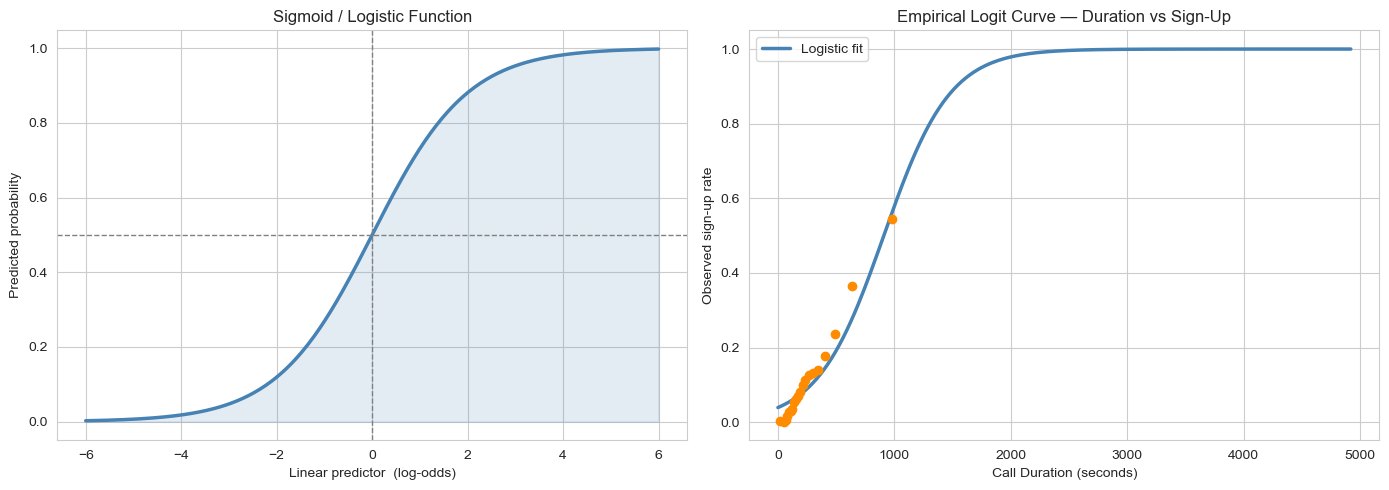

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- left: theoretical sigmoid ---
x = np.linspace(-6, 6, 300)
sigmoid = 1 / (1 + np.exp(-x))
axes[0].plot(x, sigmoid, lw=2.5, color='steelblue')
axes[0].axhline(0.5, color='grey', linestyle='--', lw=1)
axes[0].axvline(0, color='grey', linestyle='--', lw=1)
axes[0].set_xlabel('Linear predictor  (log-odds)')
axes[0].set_ylabel('Predicted probability')
axes[0].set_title('Sigmoid / Logistic Function')
axes[0].fill_between(x, sigmoid, alpha=0.15, color='steelblue')

# --- right: empirical S-curve from duration bins ---
df['duration_bin'] = pd.qcut(df['duration'], q=20)
bin_rates = df.groupby('duration_bin', observed=True)['signed up'].mean().reset_index()
bin_midpoints = df.groupby('duration_bin', observed=True)['duration'].median().values

axes[1].scatter(bin_midpoints, bin_rates['signed up'], color='darkorange', zorder=3)

# fit a simple logistic regression for the curve overlay
from sklearn.linear_model import LogisticRegression as LR
Xd = df[['duration']].values
yd = df['signed up'].values
lr_simple = LR().fit(StandardScaler().fit_transform(Xd), yd)
x_range = np.linspace(Xd.min(), Xd.max(), 300).reshape(-1, 1)
p_range = lr_simple.predict_proba(StandardScaler().fit(Xd).transform(x_range))[:, 1]
axes[1].plot(x_range, p_range, lw=2.5, color='steelblue', label='Logistic fit')
axes[1].set_xlabel('Call Duration (seconds)')
axes[1].set_ylabel('Observed sign-up rate')
axes[1].set_title('Empirical Logit Curve — Duration vs Sign-Up')
axes[1].legend()

plt.tight_layout()
plt.show()

df.drop(columns='duration_bin', inplace=True)

In [ ]:

# LogisticRegression arguments (constructor + key method args) with short explanations

arg_explanations = {
    "penalty": "Regularization type: 'l1', 'l2', 'elasticnet', or None.",
    "dual": "Use dual formulation (only for l2 + liblinear; usually False).",
    "tol": "Stopping tolerance for optimization.",
    "C": "Inverse regularization strength (smaller C => stronger regularization).",
    "fit_intercept": "Whether to estimate an intercept term.",
    "intercept_scaling": "Scaling for synthetic intercept feature (used by liblinear when fit_intercept=True).",
    "class_weight": "Class weighting (e.g., 'balanced') to handle imbalance.",
    "random_state": "Seed for reproducibility (used by some solvers/settings).",
    "solver": "Optimization algorithm ('lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga').",
    "max_iter": "Maximum number of solver iterations.",
    "multi_class": "Multiclass strategy ('auto', 'ovr', 'multinomial'; behavior depends on sklearn version).",
    "verbose": "Verbosity level from the solver.",
    "warm_start": "Reuse previous solution as initialization for next fit.",
    "n_jobs": "Number of CPU cores for parallelism (mainly relevant for OvR settings).",
    "l1_ratio": "Elastic-net mixing parameter (only when penalty='elasticnet').",
}

#print the above list into a table format using pandas DataFrame, with columns 'Argument' and 'Explanation'
arg_df = pd.DataFrame(list(arg_explanations.items()), columns=['Argument', 'Explanation'])
print(arg_df)   


             Argument                                        Explanation
0             penalty  Regularization type: 'l1', 'l2', 'elasticnet',...
1                dual  Use dual formulation (only for l2 + liblinear;...
2                 tol               Stopping tolerance for optimization.
3                   C  Inverse regularization strength (smaller C => ...
4       fit_intercept             Whether to estimate an intercept term.
5   intercept_scaling  Scaling for synthetic intercept feature (used ...
6        class_weight  Class weighting (e.g., 'balanced') to handle i...
7        random_state  Seed for reproducibility (used by some solvers...
8              solver  Optimization algorithm ('lbfgs', 'liblinear', ...
9            max_iter               Maximum number of solver iterations.
10        multi_class  Multiclass strategy ('auto', 'ovr', 'multinomi...
11            verbose                   Verbosity level from the solver.
12         warm_start  Reuse previous solution as i

---
## 4 Model 1: Simple Baseline

**What this model does:**
- No feature transformations — raw numeric values are used as-is
- Categorical features encoded with **one-hot encoding** (sklearn `OneHotEncoder`)
- Standard **train / test split** (80/20, stratified on the target)
- Default `LogisticRegression` solver (`lbfgs`) — no regularisation tuning

> **In-class note:** Even the simplest sklearn pipeline handles missing-column alignment for you — once `fit()` is called on the training set, the same transformations are applied to the test set automatically.

In [ ]:
CATEGORICAL = ['job', 'marital', 'education', 'default', 'housing', 'contact', 'poutcome']
NUMERIC     = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
TARGET      = 'signed up'

X = df[CATEGORICAL + NUMERIC]
y = df[TARGET]

# Train / Test split (stratified to preserve the ~12 % positive rate)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 34902 rows | Test: 8726 rows


In [ ]:
# sklearn Pipeline: New Concept 
preprocessor_m1 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL),
    ('num', 'passthrough', NUMERIC) # numerics passed through unchanged
])

pipe_m1 = Pipeline(steps=[
    ('prep',  preprocessor_m1),
    ('model', LogisticRegression(max_iter=5000, random_state=42, n_jobs=-1))
])

pipe_m1.fit(X_train, y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


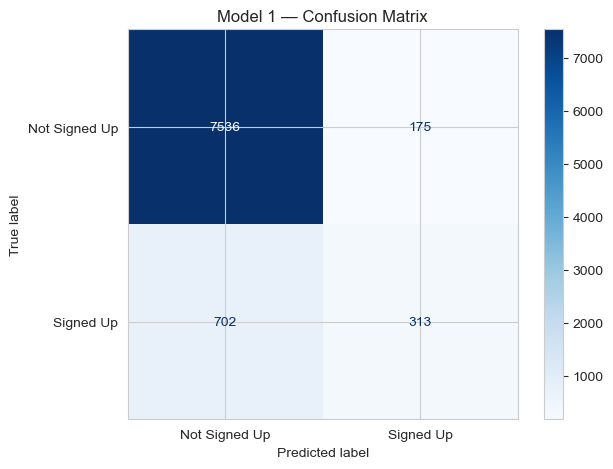

               precision    recall  f1-score   support

Not Signed Up       0.91      0.98      0.95      7711
    Signed Up       0.64      0.31      0.42      1015

     accuracy                           0.90      8726
    macro avg       0.78      0.64      0.68      8726
 weighted avg       0.88      0.90      0.88      8726



In [ ]:
y_pred_m1 = pipe_m1.predict(X_test)
cm_m1 = confusion_matrix(y_test, y_pred_m1)
disp_m1 = ConfusionMatrixDisplay(confusion_matrix=cm_m1, display_labels=['Not Signed Up', 'Signed Up'])
disp_m1.plot(cmap='Blues')
plt.title('Model 1 — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_m1, target_names=['Not Signed Up', 'Signed Up']))

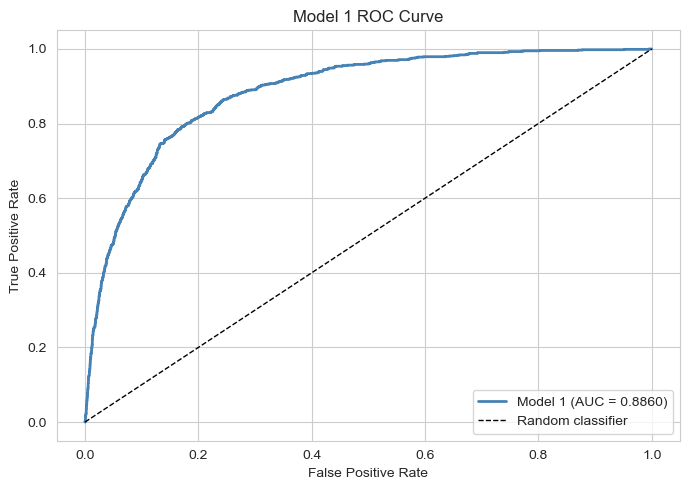

Model 1 ROC-AUC: 0.8860


In [ ]:
y_proba_m1= pipe_m1.predict_proba(X_test)[:, 1]

fpr_m1, tpr_m1, thresholds = roc_curve(y_test, y_proba_m1)
auc_m1 = roc_auc_score(y_test, y_proba_m1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m1, tpr_m1, lw=2, color='steelblue', label=f'Model 1 (AUC = {auc_m1:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 1 ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 1 ROC-AUC: {auc_m1:.4f}")

### 4.1 — Top Coefficients (Model 1)

Positive coefficients increase the log-odds of signing up; negative ones decrease it.

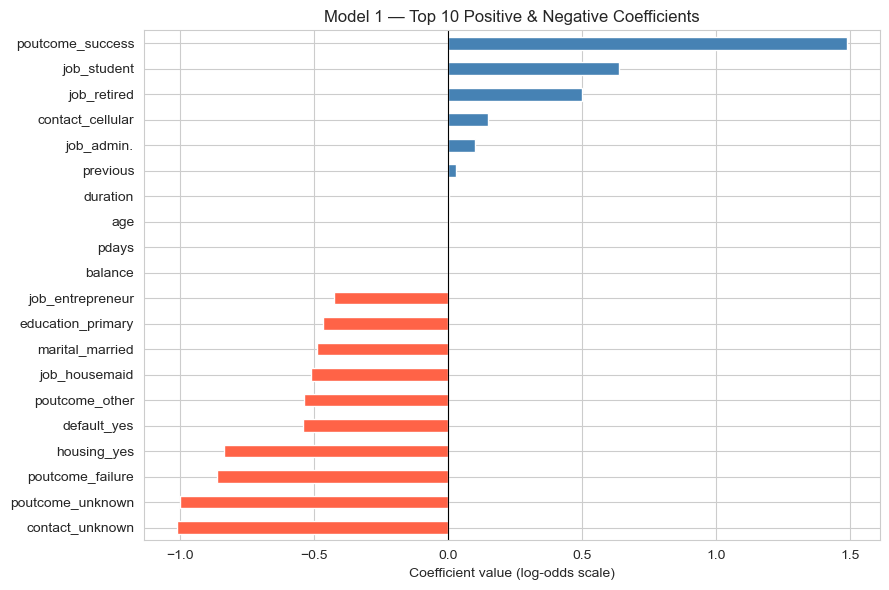

In [ ]:
ohe_features = pipe_m1.named_steps['prep'].transformers_[0][1].get_feature_names_out(CATEGORICAL)
feature_names_m1 = list(ohe_features) + NUMERIC
coefs_m1 = pd.Series(
    pipe_m1.named_steps['model'].coef_[0],
    index=feature_names_m1
).sort_values()

# Show top 10 positive and top 10 negative
top_coefs = pd.concat([coefs_m1.head(10), coefs_m1.tail(10)])
top_coefs.plot(kind='barh', figsize=(9, 6), color=top_coefs.map(lambda v: 'steelblue' if v >= 0 else 'tomato'))
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Model 1 — Top 10 Positive & Negative Coefficients')
plt.xlabel('Coefficient value (log-odds scale)')
plt.tight_layout()
plt.show()

---
## 5 — Model 2: Complex Model with Transformations & Interactions

**What this model adds:**
- **Log-transforms** on right-skewed numeric features (`balance`, `duration`, `campaign`) to pull in extreme outliers
- **Interaction terms**: `log_duration × log_campaign` and `log_duration × poutcome_success` — short calls after a previous success are different from long cold calls
- `pdays` recoded to a binary flag (`was_contacted`) since most values are -1 (never contacted)
- **StandardScaler** on all numeric inputs so regularisation penalises features equally
- Stronger L2 regularisation (`C=0.1`) to control the richer feature space

In [ ]:
# ── Skewness check before transformation ───────────────────────────────────────
skew_cols = ['balance', 'duration', 'campaign', 'pdays', 'previous']
print("Skewness (raw):")
print(df[skew_cols].skew().round(2))

Skewness (raw):
balance      8.46
duration     3.16
campaign     4.89
pdays        2.61
previous    42.27
dtype: float64


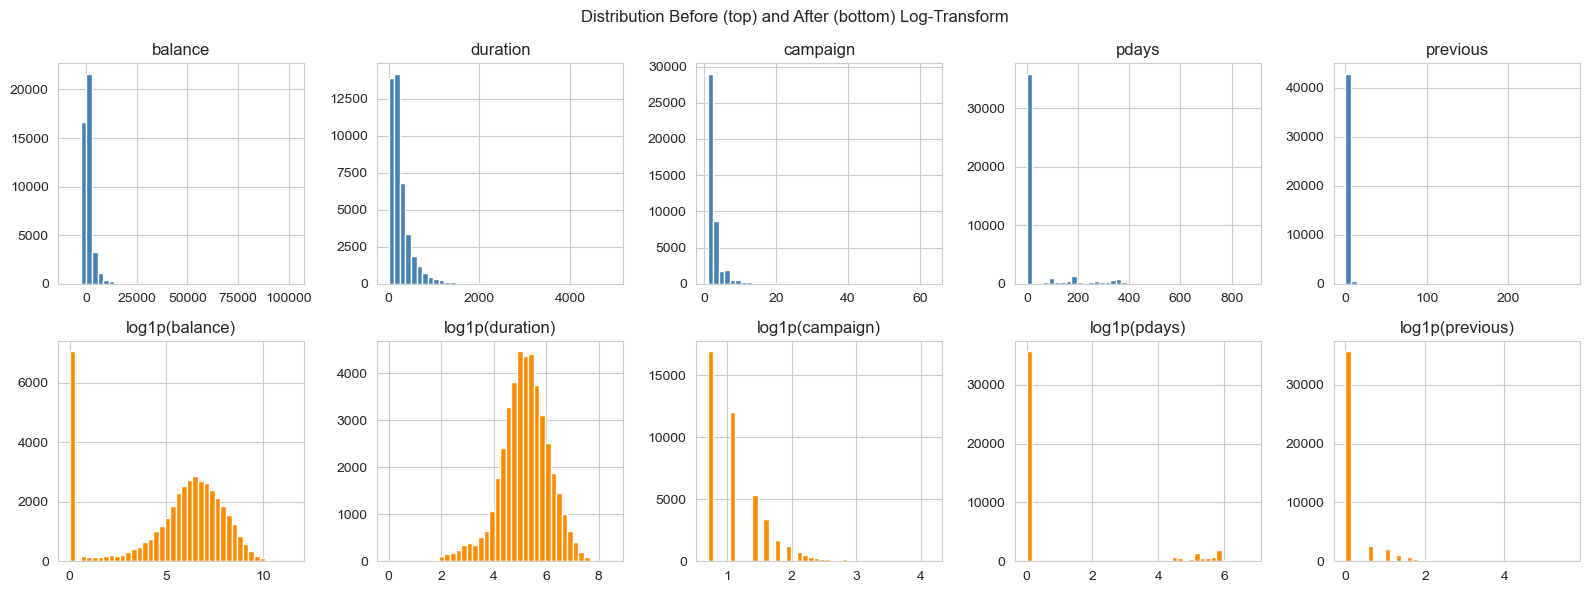

In [ ]:
fig, axes = plt.subplots(2, len(skew_cols), figsize=(16, 6))
fig.suptitle('Distribution Before (top) and After (bottom) Log-Transform', fontsize=12)
for i, col in enumerate(skew_cols):
    axes[0, i].hist(df[col], bins=40, color='steelblue', edgecolor='white')
    axes[0, i].set_title(col)
    transformed = np.log1p(np.maximum(df[col], 0))   # log1p handles zeros
    axes[1, i].hist(transformed, bins=40, color='darkorange', edgecolor='white')
    axes[1, i].set_title(f'log1p({col})')
plt.tight_layout()
plt.show()

In [ ]:
# Just adding some features to see if we can get a boost in performance. 
# We won't do any scaling or regularization for now, 
# just a simple logistic regression with some engineered features.


def build_model2_features(df_input):
    """Engineer features for Model 2 and return an (X, feature_names) tuple."""
    d = df_input.copy()

    # Log-transforms (log1p is safe for zeros; clip negatives first for balance)
    d['log_balance']  = np.log1p(np.maximum(d['balance'],  0))
    d['log_duration'] = np.log1p(d['duration'])
    d['log_campaign'] = np.log1p(d['campaign'])
    d['log_previous'] = np.log1p(d['previous'])

    # Binary flag: was the client previously contacted?
    d['was_contacted'] = (d['pdays'] != -1).astype(int)

    # Interaction: long calls after previous success are strong predictors
    d['dur_x_campaign']  = d['log_duration'] * d['log_campaign']
    d['dur_x_contacted'] = d['log_duration'] * d['was_contacted']

    cat_cols = CATEGORICAL
    num_cols = ['age', 'log_balance', 'log_duration', 'log_campaign',
                'log_previous', 'was_contacted', 'dur_x_campaign', 'dur_x_contacted']

    return d[cat_cols + num_cols], cat_cols, num_cols


X2_all, cat2, num2 = build_model2_features(df)
y2 = df[TARGET]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2_all, y2, test_size=0.20, random_state=42, stratify=y2
)
print(f"Model 2 — Train: {X2_train.shape[0]:,} | Test: {X2_test.shape[0]:,}")

Model 2 — Train: 34,902 | Test: 8,726


In [ ]:
preprocessor_m2 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat2),
    ('num', StandardScaler(), num2)
])

pipe_m2 = Pipeline(steps=[
    ('prep',  preprocessor_m2),
    ('model', LogisticRegression(max_iter=5000, random_state=42))
])

pipe_m2.fit(X2_train, y2_train)
print("Model 2 fitted.")

Model 2 fitted.


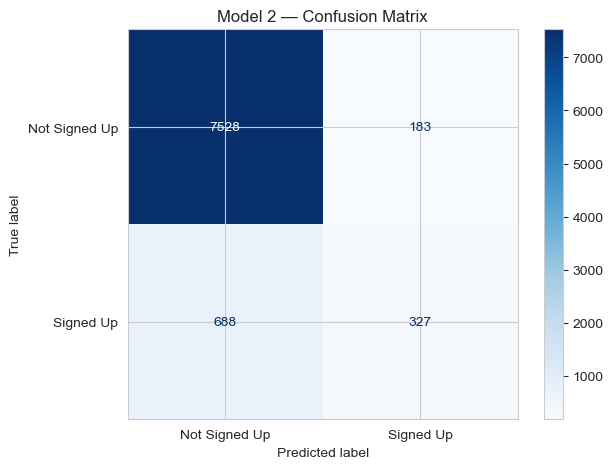

               precision    recall  f1-score   support

Not Signed Up       0.92      0.98      0.95      7711
    Signed Up       0.64      0.32      0.43      1015

     accuracy                           0.90      8726
    macro avg       0.78      0.65      0.69      8726
 weighted avg       0.88      0.90      0.89      8726



In [ ]:
y_pred_m2 = pipe_m2.predict(X2_test)
cm_m2 = confusion_matrix(y2_test, y_pred_m2)
disp_m2 = ConfusionMatrixDisplay(confusion_matrix=cm_m2, display_labels=['Not Signed Up', 'Signed Up'])
disp_m2.plot(cmap='Blues')
plt.title('Model 2 — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y2_test, y_pred_m2, target_names=['Not Signed Up', 'Signed Up']))

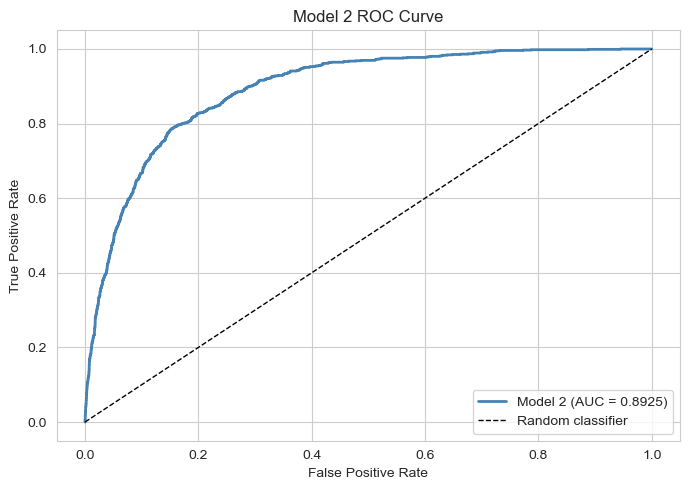

Model 2 ROC-AUC: 0.8925


In [ ]:
y_proba_m2 = pipe_m2.predict_proba(X2_test)[:, 1]
fpr_m2, tpr_m2, thresholds_m2 = roc_curve(y2_test, y_proba_m2)
auc_m2 = roc_auc_score(y2_test, y_proba_m2)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m2, tpr_m2, lw=2, color='steelblue', label=f'Model 2 (AUC = {auc_m2:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 2 ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 2 ROC-AUC: {auc_m2:.4f}")

### 5.1 — Top Coefficients (Model 2)

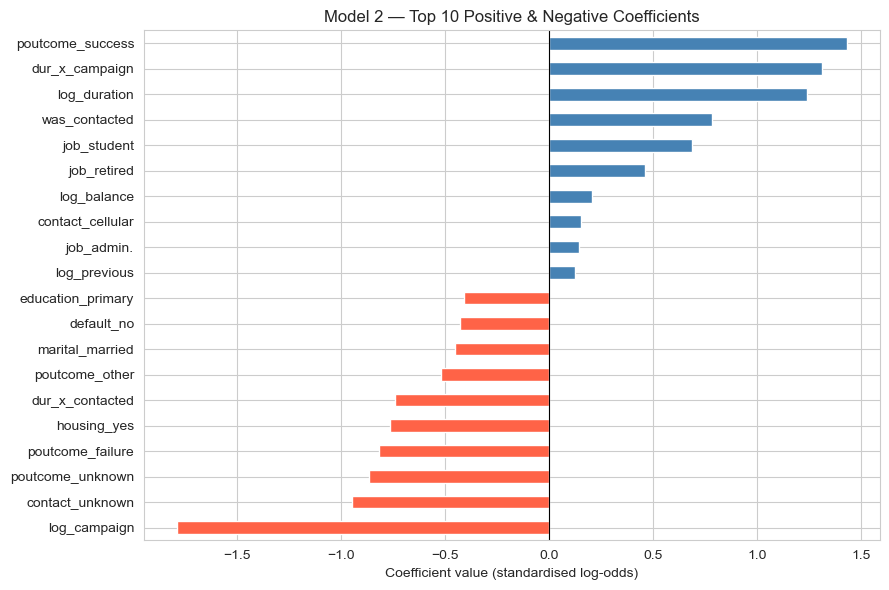

In [ ]:
ohe_features_m2 = pipe_m2.named_steps['prep'].transformers_[0][1].get_feature_names_out(cat2)
feature_names_m2 = list(ohe_features_m2) + num2
coefs_m2 = pd.Series(
    pipe_m2.named_steps['model'].coef_[0],
    index=feature_names_m2
).sort_values()

top_coefs_m2 = pd.concat([coefs_m2.head(10), coefs_m2.tail(10)])
top_coefs_m2.plot(kind='barh', figsize=(9, 6),
                  color=top_coefs_m2.map(lambda v: 'steelblue' if v >= 0 else 'tomato'))
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Model 2 — Top 10 Positive & Negative Coefficients')
plt.xlabel('Coefficient value (standardised log-odds)')
plt.tight_layout()
plt.show()

---
## 6 — Model 3: Final Model — Cross-Validation, Gradient Descent & Calibration

**What this model adds:**
- Uses the **same high-quality features** as Model 2
- Replaces `lbfgs` with **stochastic gradient descent** (`SGDClassifier` with `loss='log_loss'`) to demonstrate gradient-descent-based optimisation
- Wraps the whole thing in **5-fold stratified cross-validation** to get a stable performance estimate without a fixed train/test split
- Applies **isotonic probability calibration** (`CalibratedClassifierCV`) so that predicted probabilities are more reliable (important for business decisions like setting call-priority thresholds)

> **In-class note:** Cross-validation avoids "lucky" splits and gives a better estimate of generalisation error. Calibration ensures predicted *probabilities* (not just rankings) are trustworthy.

In [ ]:
# Reuse the same feature matrix as Model 2
X3_train, X3_test, y3_train, y3_test = X2_train, X2_test, y2_train, y2_test

# SGDClassifier with log-loss == logistic regression optimized via SGD
sgd_lr = SGDClassifier(
    loss='log_loss',
    penalty='l2',
    alpha=0.01,  # regularization strength
    max_iter=5000,
    random_state=42,
    class_weight='balanced'   # counter-act the ~12 % positive class
)

preprocessor_m3 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat2),
    ('num', StandardScaler(), num2)
])

base_pipe = Pipeline(steps=[
    ('prep',  preprocessor_m3),
    ('model', sgd_lr)
])

# Isotonic calibration — learns a monotone mapping from raw scores to probabilities
pipe_m3 = CalibratedClassifierCV(base_pipe, method='isotonic', cv=5)
pipe_m3.fit(X3_train, y3_train)
print("Model 3 (calibrated SGD) fitted.")

Model 3 (calibrated SGD) fitted.


### 6.1 — 5-Fold Stratified Cross-Validation

We refit a `Pipeline` with an **uncalibrated** SGD classifier for cross-validation scoring (calibration is done separately above).

5-Fold Cross-Validation Results (SGD Logistic Regression):
  ROC-AUC : 0.8895  ± 0.0016  | folds: [0.8906 0.8872 0.8919 0.8893 0.8887]
  F1      : 0.4905  ± 0.0061  | folds: [0.5003 0.4815 0.4889 0.4926 0.489 ]


C:\Users\CybCy\AppData\Local\Temp\ipykernel_27084\609497405.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([cv_auc], labels=['AUC'], patch_artist=True,


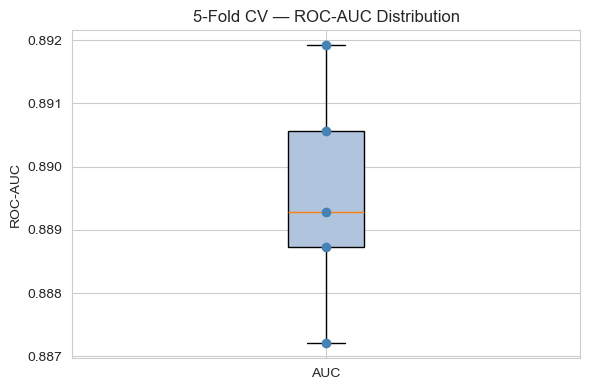

In [ ]:
# Cross-validate the SGD pipeline (without calibration wrapper for simplicity)
cv_pipe = Pipeline(steps=[
    ('prep',  ColumnTransformer(transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat2),
        ('num', StandardScaler(), num2)
    ])),
    ('model', SGDClassifier(loss='log_loss', penalty='l2', alpha=0.01,
                            max_iter=1000, random_state=42, class_weight='balanced'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_auc  = cross_val_score(cv_pipe, X2_all, y2, cv=cv, scoring='roc_auc')
cv_f1   = cross_val_score(cv_pipe, X2_all, y2, cv=cv, scoring='f1')

print("5-Fold Cross-Validation Results (SGD Logistic Regression):")
print(f"  ROC-AUC : {cv_auc.mean():.4f}  ± {cv_auc.std():.4f}  | folds: {np.round(cv_auc, 4)}")
print(f"  F1      : {cv_f1.mean():.4f}  ± {cv_f1.std():.4f}  | folds: {np.round(cv_f1, 4)}")

# Box-plot of fold AUCs
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([cv_auc], labels=['AUC'], patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue'))
ax.scatter([1]*5, cv_auc, color='steelblue', zorder=3)
ax.set_title('5-Fold CV — ROC-AUC Distribution')
ax.set_ylabel('ROC-AUC')
plt.tight_layout()
plt.show()

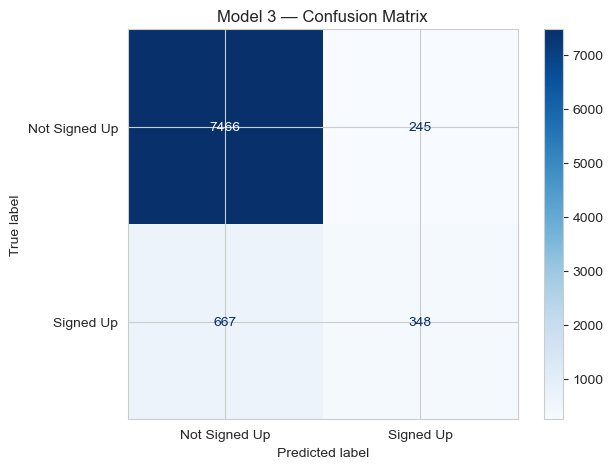

               precision    recall  f1-score   support

Not Signed Up       0.92      0.97      0.94      7711
    Signed Up       0.59      0.34      0.43      1015

     accuracy                           0.90      8726
    macro avg       0.75      0.66      0.69      8726
 weighted avg       0.88      0.90      0.88      8726



In [ ]:
y_pred_m3 = pipe_m3.predict(X3_test)
cm_m3 = confusion_matrix(y3_test, y_pred_m3)
disp_m3 = ConfusionMatrixDisplay(confusion_matrix=cm_m3, display_labels=['Not Signed Up', 'Signed Up'])
disp_m3.plot(cmap='Blues')
plt.title('Model 3 — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y3_test, y_pred_m3, target_names=['Not Signed Up', 'Signed Up']))

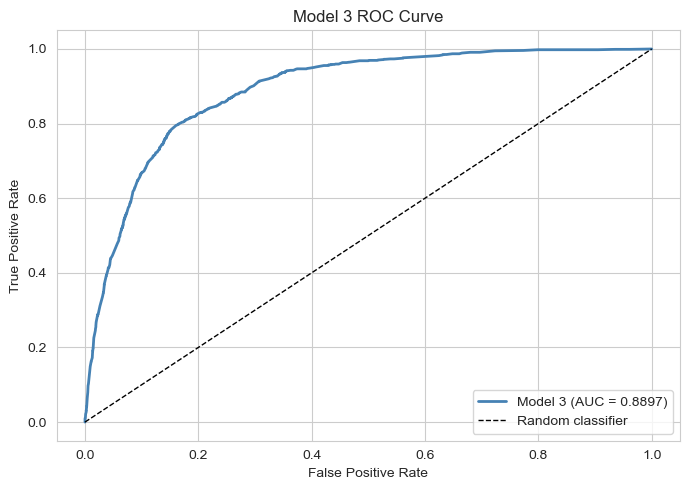

Model 3 ROC-AUC: 0.8897


In [ ]:
y_proba_m3 = pipe_m3.predict_proba(X3_test)[:, 1]
fpr_m3, tpr_m3, thresholds_m3 = roc_curve(y3_test, y_proba_m3)
auc_m3 = roc_auc_score(y3_test, y_proba_m3)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m3, tpr_m3, lw=2, color='steelblue', label=f'Model 3 (AUC = {auc_m3:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 3 ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 3 ROC-AUC: {auc_m3:.4f}")

### 6.2 — Calibration Curve

A **well-calibrated** model's predicted probabilities match observed frequencies.  
A perfect calibration curve lies on the diagonal.

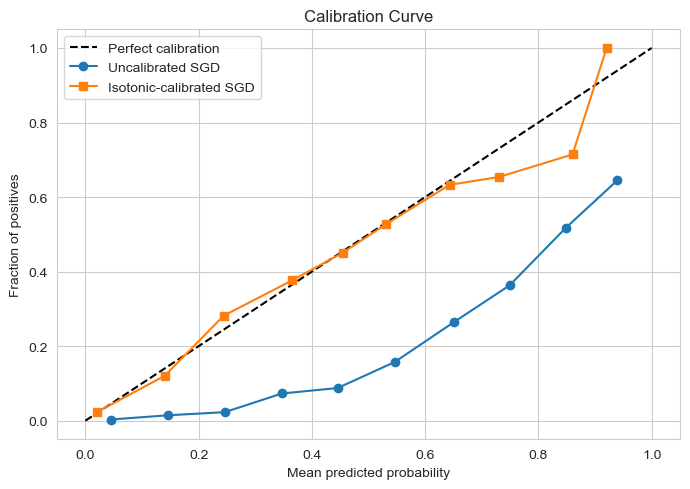

In [ ]:
# Uncalibrated SGD probabilities vs calibrated
sgd_uncal = Pipeline(steps=[
    ('prep',  ColumnTransformer(transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat2),
        ('num', StandardScaler(), num2)
    ])),
    ('model', SGDClassifier(loss='log_loss', penalty='l2', alpha=0.01,
                            max_iter=1000, random_state=42, class_weight='balanced'))
])
sgd_uncal.fit(X3_train, y3_train)

prob_uncal = sgd_uncal.predict_proba(X3_test)[:, 1]
prob_cal   = pipe_m3.predict_proba(X3_test)[:, 1]

frac_pos_u, mean_pred_u = calibration_curve(y3_test, prob_uncal, n_bins=10)
frac_pos_c, mean_pred_c = calibration_curve(y3_test, prob_cal,   n_bins=10)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.plot(mean_pred_u, frac_pos_u, marker='o', label='Uncalibrated SGD')
ax.plot(mean_pred_c, frac_pos_c, marker='s', label='Isotonic-calibrated SGD')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration Curve')
ax.legend()
plt.tight_layout()
plt.show()

---
## 7 — Model Comparison Summary

In [ ]:
summary = pd.DataFrame({
    'Model': [
        'Model 1 — Simple Baseline',
        'Model 2 — Transformations & Interactions',
        'Model 3 — SGD + Calibration'
    ],
    'ROC-AUC (test)': [round(auc_m1, 4), round(auc_m2, 4), round(auc_m3, 4)],
    'CV ROC-AUC (mean)': [None, None, round(cv_auc.mean(), 4)],
    'Key additions': [
        'One-hot encoding, train/test split',
        '+ log transforms, interaction terms, StandardScaler, C=0.1',
        '+ SGD optimiser, class_weight=balanced, isotonic calibration, 5-fold CV'
    ]
})
summary

,Model,ROC-AUC (test),CV ROC-AUC (mean),Key additions
0,Model 1 — Simple Baseline,0.8860,NaN,"One-hot encoding, train/test split"
1,Model 2 — Transformations & Interactions,0.8925,NaN,"+ log transforms, interaction terms, StandardS..."
2,Model 3 — SGD + Calibration,0.8897,0.8895,"+ SGD optimiser, class_weight=balanced, isoton..."


---
## 8 — Calibration & Threshold Selection

Choosing the decision threshold (default 0.50) is a **business decision**, not a statistical one.  
The plot below shows how **precision** and **recall** trade off as the threshold changes for Model 3.

- **Low threshold** → catch more sign-ups (high recall) but more false alarms (lower precision)
- **High threshold** → very confident calls only (high precision) but misses many true sign-ups

> **In-class discussion:** If calling a customer costs \$5 and a conversion is worth \$200, what threshold maximises expected profit?

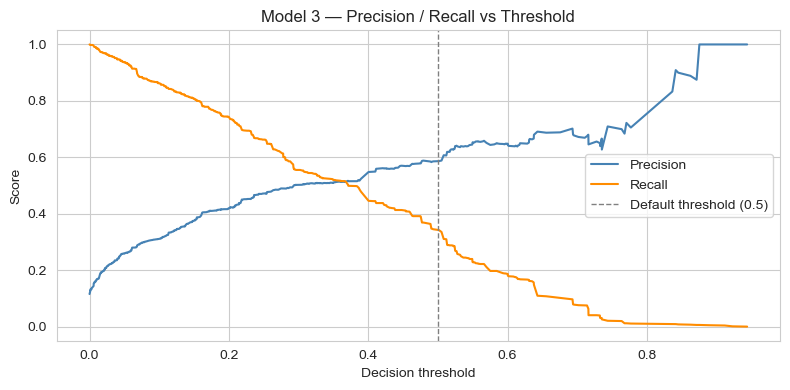

In [ ]:
from sklearn.metrics import precision_recall_curve

probs_m3 = pipe_m3.predict_proba(X3_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y3_test, probs_m3)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, precision[:-1], label='Precision', color='steelblue')
ax.plot(thresholds, recall[:-1],    label='Recall',    color='darkorange')
ax.axvline(0.5, color='grey', linestyle='--', linewidth=1, label='Default threshold (0.5)')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_title('Model 3 — Precision / Recall vs Threshold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 9 — Key Takeaways

| Concept | What we did |
|---|---|
| **Logit curve** | Visualised the sigmoid function and the empirical S-curve for call duration |
| **One-hot encoding** | Converted categorical features into binary dummy columns inside the pipeline |
| **Train / test split** | Stratified 80/20 split to preserve class balance across sets |
| **Log-transforms** | Reduced right-skew in balance, duration, and campaign |
| **Interaction terms** | Captured the combined effect of duration × campaign contacts |
| **Regularisation** | `C=0.1` (L2) penalises large coefficients and reduces overfitting |
| **SGD (gradient descent)** | `SGDClassifier(loss='log_loss')` fits logistic regression via mini-batch SGD |
| **Cross-validation** | 5-fold CV gives a more reliable AUC estimate than a single split |
| **Calibration** | Isotonic regression maps raw probabilities to calibrated ones |
| **Confusion matrix** | Shows TP/FP/TN/FN counts; useful for understanding misclassification costs |
| **ROC-AUC** | Threshold-independent measure of discriminative ability |
| **Threshold selection** | Business-driven choice balancing precision vs recall |